In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = np.load("SAGE_GridSearch_2/Data/4_100s.npz", allow_pickle=True)
input_data = data['input_data']
time_data = data['time_data']
output_data = data['output_data']
input_data = input_data[:, np.newaxis]
input_data = -1 + (input_data - np.min(input_data)) / (np.max(input_data) - np.min(input_data)) * (1 - (-1))

print(input_data.shape, time_data.shape, output_data.shape)

X = output_data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # shape (T, F)

(25001, 1) (25001,) (25001, 32)


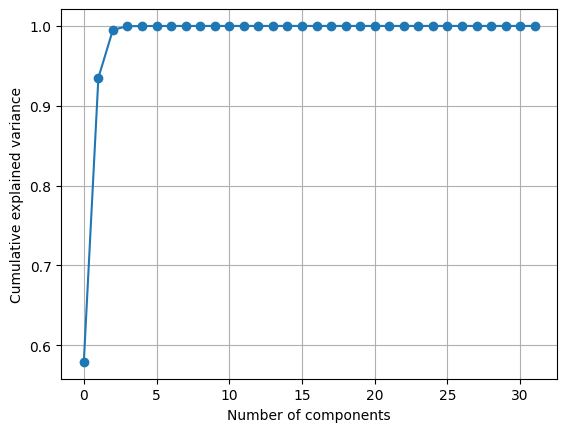

In [2]:
n_components = X_scaled.shape[1]  # choose how many PCs you want
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
expl_var = pca.explained_variance_ratio_

plt.plot(np.cumsum(expl_var), '-o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

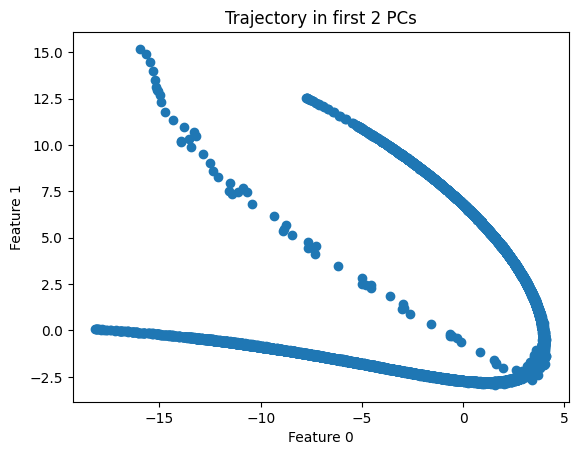

In [3]:
n_components = 6  # choose how many PCs you want
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
expl_var = pca.explained_variance_ratio_

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Trajectory in first 2 PCs")
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.special import legendre

def nonlinearity_testing(input, output, leg_max_order, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    else:
        print("Please specify the regressor")

    x = output
    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    for n in range(1, leg_max_order+1):
        leg = legendre(n)
        y = leg(input)
        shape_input = input.shape
        train_size = int(shape_input[0] * (1 - test_size))
        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)

        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
        clf.fit(x_train, y_train)

        # Training
        y_train_pred = clf.predict(x_train)
        # print(y_train.shape, train_size, input.shape)

        MSE_train = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE_train/y2
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 2)
        y_test_pred[idx] = np.mean(y)
        y_test[idx, 0] = np.mean(y)

        MSE_test = mean_squared_error(y_true=y_test, y_pred=y_test_pred) #1/(len(y_test)) * (y_test[:, 0]-y_test_pred)**2
        # print(y_test.shape, y_test_pred.shape, MSE_test.shape)
        # plt.plot((y_test[:, 0]-y_test_pred)**2)
        # plt.title(f'MSE Test {n}')
        # plt.show()
        capacity_test = 1 - MSE_test/y2
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # print("legendre", n, "MSE", MSE_train, MSE_test, "y2", y2, "capacity", capacity_train, capacity_test)

        # plt.figure(figsize=(15, 5))
        # plt.subplot(121)
        # plt.scatter(input[:train_size, :], y_train, label='True')
        # plt.scatter(input[:train_size, :],y_train_pred, label='Predicted')
        # plt.title(f'Training Legendre {n}')
        # plt.legend()
        # plt.grid()

        # plt.subplot(122)
        # plt.scatter(input[train_size:, :], y_test, label='True')
        # plt.scatter(input[train_size:, :], y_test_pred, label='Predicted')
        # plt.title(f'Testing Legendre {n}')
        # plt.legend()
        # plt.grid()

        # plt.show()     

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

def memory_testing(input, output, max_timesteps_back, regressor, test_size, alpha, sample_freq):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    else:
        print("Please specify the regressor")

    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    for n in range(0, max_timesteps_back+1):
        x = output[n:]
        if n == 0:
            y = input
        else:
            y = input[:-n]

        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
        clf.fit(x_train, y_train)

        # Training
        y_train_pred = clf.predict(x_train)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx, 0] = np.mean(y)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # plt.figure(figsize=(15, 5))
        # plt.subplot(121)
        # plt.scatter(y_train, y_train, label='True')
        # plt.plot(y_train_pred, label='Predicted')
        # plt.title(f'Training Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.subplot(122)
        # plt.plot(y_test, label='True')
        # plt.plot(y_test_pred, label='Predicted')
        # plt.title(f'Testing Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.show()

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

        # print("memory", n, R2_train, R2_test, capacity_train, capacity_test)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

In [8]:
print(input_data.shape, X_pca.shape)

# Nonlinearity testing
leg_max_order = 10
regressor = "Rid"
test_size = 0.25
alpha = 0.0001
leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output_data, leg_max_order, regressor, test_size, alpha)
leg_capacity_train_list_pca, leg_capacity_test_list_pca, leg_R2_train_list_pca, leg_R2_test_list_pca = nonlinearity_testing(input_data, X_pca, leg_max_order, regressor, test_size, alpha)

# Memory testing
sample_freq = 5
max_time_back_seconds = 1
max_timesteps_back = np.rint(sample_freq*max_time_back_seconds).astype(int)
# max_timesteps_back = 10
# max_time_back_seconds = np.rint(max_timesteps_back/sample_freq).astype(int)
regressor = "Rid"
test_size = 0.25
alpha = 0.0001
mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output_data, max_timesteps_back, regressor, test_size, alpha, sample_freq)
mem_capacity_train_list_pca, mem_capacity_test_list_pca, mem_R2_train_list_pca, mem_R2_test_list_pca = memory_testing(input_data, X_pca, max_timesteps_back, regressor, test_size, alpha, sample_freq)

onl = sum(leg_capacity_test_list)/len(leg_capacity_test_list)
oml = sum(mem_capacity_test_list)/len(mem_capacity_test_list)
onl_pca = sum(leg_capacity_test_list_pca)/len(leg_capacity_test_list_pca)
oml_pca = sum(mem_capacity_test_list_pca)/len(mem_capacity_test_list_pca)

print(f"Without PCA ONL={onl}, OML={oml}")
print(f"With PCA-{n_components} ONL={onl_pca}, OML={oml_pca}")

(25001, 1) (25001, 6)
Without PCA ONL=0.731716341439985, OML=0.9989180562201723
With PCA-6 ONL=0.5141511205612646, OML=0.9878111490749423


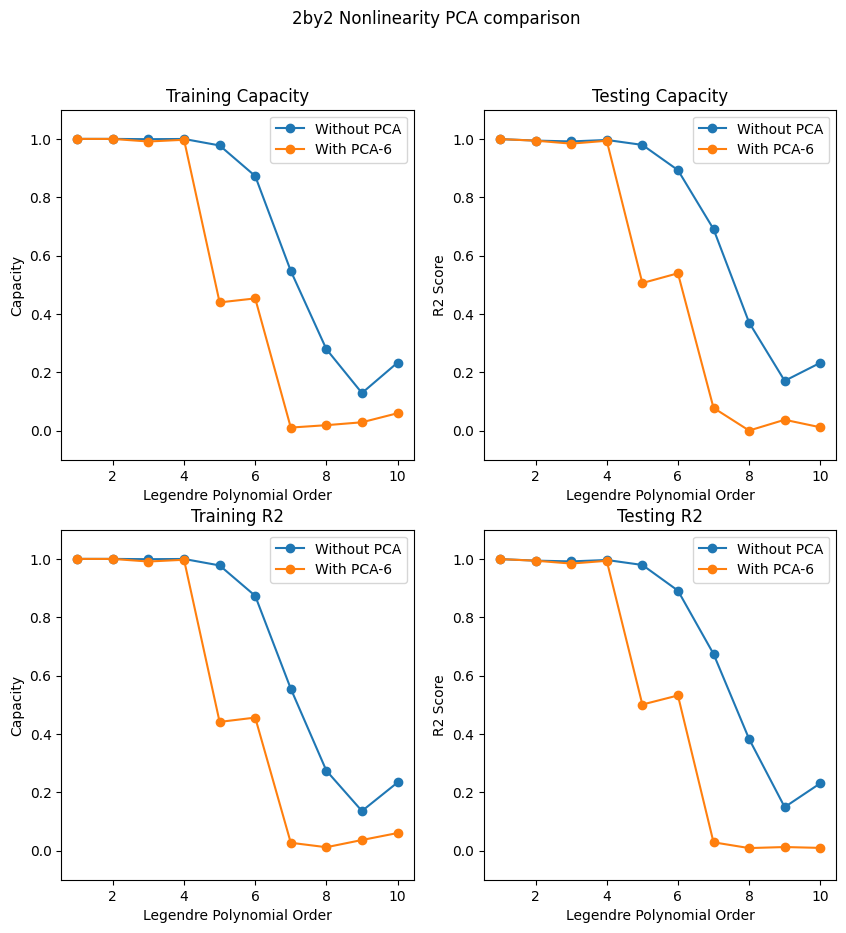

In [9]:
figleg, axleg = plt.subplots(2, 2, figsize=(10, 10))
figleg.suptitle(f"2by2 Nonlinearity PCA comparison")
for m in range(axleg.shape[0]):
    for k in range(axleg.shape[1]):
        ylabel = "Capacity" if k == 0 else "R2 Score"
        ax = axleg[m, k]
        ax.set_xlabel("Legendre Polynomial Order")
        ax.set_ylabel(ylabel)
        ax.set_ylim(-0.1, 1.1)
axleg[0, 0].set_title("Training Capacity")
axleg[0, 1].set_title("Testing Capacity")
axleg[1, 0].set_title("Training R2")
axleg[1, 1].set_title("Testing R2")

axleg[0, 0].plot(np.linspace(1, leg_max_order, leg_max_order), leg_capacity_train_list, '-o', label="Without PCA")
axleg[0, 1].plot(np.linspace(1, leg_max_order, leg_max_order), leg_capacity_test_list, '-o', label="Without PCA")
axleg[1, 0].plot(np.linspace(1, leg_max_order, leg_max_order), leg_R2_train_list, '-o', label="Without PCA")
axleg[1, 1].plot(np.linspace(1, leg_max_order, leg_max_order), leg_R2_test_list, '-o', label="Without PCA")

axleg[0, 0].plot(np.linspace(1, leg_max_order, leg_max_order), leg_capacity_train_list_pca, '-o', label=f"With PCA-{n_components}")
axleg[0, 1].plot(np.linspace(1, leg_max_order, leg_max_order), leg_capacity_test_list_pca, '-o', label=f"With PCA-{n_components}")
axleg[1, 0].plot(np.linspace(1, leg_max_order, leg_max_order), leg_R2_train_list_pca, '-o', label=f"With PCA-{n_components}")
axleg[1, 1].plot(np.linspace(1, leg_max_order, leg_max_order), leg_R2_test_list_pca, '-o', label=f"With PCA-{n_components}")

axleg[0, 0].legend()
axleg[0, 1].legend()
axleg[1, 0].legend()
axleg[1, 1].legend()

plt.show()

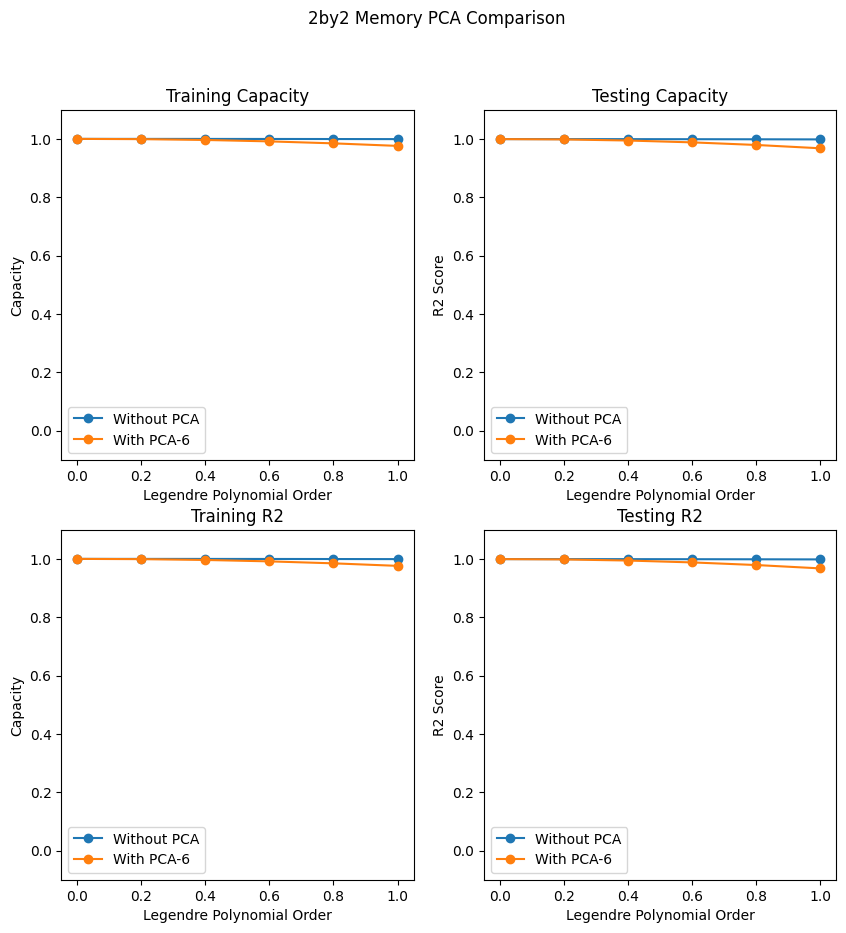

In [10]:
figmem, axmem = plt.subplots(2, 2, figsize=(10, 10))
figmem.suptitle(f"2by2 Memory PCA Comparison")
for m in range(axmem.shape[0]):
    for k in range(axmem.shape[1]):
        ylabel = "Capacity" if k == 0 else "R2 Score"
        ax = axmem[m, k]
        ax.set_xlabel("Legendre Polynomial Order")
        ax.set_ylabel(ylabel)
        ax.set_ylim(-0.1, 1.1)

axmem[0, 0].set_title("Training Capacity")
axmem[0, 1].set_title("Testing Capacity")
axmem[1, 0].set_title("Training R2")
axmem[1, 1].set_title("Testing R2")

axmem[0, 0].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_capacity_train_list, '-o', label="Without PCA")
axmem[0, 1].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_capacity_test_list, '-o', label="Without PCA")
axmem[1, 0].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_R2_train_list, '-o', label="Without PCA")
axmem[1, 1].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_R2_test_list, '-o', label="Without PCA")

axmem[0, 0].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_capacity_train_list_pca, '-o', label=f"With PCA-{n_components}")
axmem[0, 1].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_capacity_test_list_pca, '-o', label=f"With PCA-{n_components}")
axmem[1, 0].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_R2_train_list_pca, '-o', label=f"With PCA-{n_components}")
axmem[1, 1].plot(np.linspace(0, max_time_back_seconds, max_timesteps_back+1), mem_R2_test_list_pca, '-o', label=f"With PCA-{n_components}")

axmem[0, 0].legend()
axmem[0, 1].legend()
axmem[1, 0].legend()
axmem[1, 1].legend()

plt.show()